## Import Packages And Define Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

#### Import TALib Only If Necessary

In [ ]:
url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
url = 'https://anaconda.org/conda-forge/ta-lib/0.4.19/download/linux-64/ta-lib-0.4.19-py310hde88566_4.tar.bz2'
!curl -L $url | tar xj -C /usr/local/lib/python3.10/dist-packages/ lib/python3.10/site-packages/talib --strip-components=3
import talib

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4428    0  4428    0     0  15679      0 --:--:-- --:--:-- --:--:-- 15702
100  517k  100  517k    0     0   654k      0 --:--:-- --:--:-- --:--:--  654k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4408    0  4408    0     0   8256      0 --:--:-- --:--:-- --:--:--  8270
100  392k  100  392k    0     0   383k      0  0:00:01  0:00:01 --:--:-- 3765k


In [ ]:
def annual_num_transaction(position):
    return sum(np.where(position != position.shift(1), 1, 0)) / len(position) * 252.

def annual_return(returns):
    return returns.mean() * 252.

def annual_volatility(returns):
    return returns.std() * (252. ** 0.5)

def cum_return(returns):
    return list(np.exp(returns.cumsum()))[-1]

def max_drawdown(returns):
    cum_returns = np.exp(returns.cumsum())
    cum_max = cum_returns.cummax()
    return ((cum_max - cum_returns) / cum_max).max()

def information_ratio(strategy_return, benchmark_return):
    track_error = annual_volatility(strategy_return - benchmark_return)
    if track_error < 1e-9:
        return 0.
    else:
        return (annual_return(strategy_return) - annual_return(benchmark_return)) / track_error

## Data Cleaning

In [ ]:
!pip install yfinance
import yfinance as yf

In [ ]:
code = [
    "^GSPC",
    "AAPL",
    "JPM",
    "GOOGL",
    "000300.SS", #HS300
    "600887.SS", #YLGF
    "600519.SS", #GZMT
    "600897.SS", #XMKG
    "601601.SS", #ZGTB
    "600188.SS", #YKNY
    "601318.SS", #ZGPA
    "600900.SS", #CJDL
    "600000.SS", #PFYH
    "002460.SZ", #GFLY
    "002033.SZ", #LJGF
]
btc = yf.download("BTC-USD", start="2014-09-30", end = "2024-01-11")
btc.columns = btc.columns.droplevel(1)
btc["Adj Close"] = btc["Close"] / 46368.585938 * 26.629999
btc["Close"] = btc["Close"] / 46368.585938 * 26.629999
btc["High"] = btc["High"] / 48969.371094 * 30.000000
btc["Low"] = btc["Low"] / 45678.644531 * 26.280001
btc["Open"] = btc["Open"] / 46656.074219 * 27.940001
btc["Volume"] = btc["Volume"] / 45833734549 * 37657300
ibit = yf.download("IBIT", start = "2024-01-11", auto_adjust = False)
ibit.columns = ibit.columns.droplevel(1)
data = pd.concat([btc[btc.index.weekday < 5], ibit], axis = 0)
# train test split
data_train = data[:"2024-12-31"]
data_train["close"] = data_train["Adj Close"]
data_train["open"] = data_train["Open"]
data_train["high"] = data_train["High"]
data_train["low"] = data_train["Low"]
data_train["return"] = np.log(data_train["close"] / data_train["close"].shift(1))
data_test = data["2023-01-01":]
data_test["close"] = data_test["Adj Close"]
data_test["open"] = data_test["Open"]
data_test["high"] = data_test["High"]
data_test["low"] = data_test["Low"]
data_test["return"] = np.log(data_test["close"] / data_test["close"].shift(1))

/tmp/ipython-input-410247841.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2014-09-30", end = "2024-01-11")
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-410247841.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train["close"] = data_train["Adj Close"]
/tmp/ipython-input-410247841.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-

## Strategy

In [ ]:
num_stds = [0., 2.0]
windows = [4, 121]
num_dyn_stop_losses = [0., 2.]
num_static_stop_losses = [0., 2.]
# num_stds = [0., 0.5, 1., 1.5, 2.0]
# windows = [4, 9, 19, 61, 121]
# num_dyn_stop_losses = [0., 0.5, 1., 1.5, 2.0]
# num_static_stop_losses = [0., 0.5, 1., 1.5, 2.0]
transaction_cost = 0.
# max history data needed
look_back_window = 365
# backtest for 24 months
backtest_length = 365 * 2
backtest_launch_points = [
    # "2007-12-31",
    # "2009-12-31",
    # "2011-12-31",
    # "2013-12-31",
    "2016-12-31",
    "2018-12-31",
    "2020-12-31",
    "2022-12-31",
    ]
performance = pd.DataFrame(columns = ["num_std",
                                      "window",
                                      "num_dyn_stop_loss",
                                      "num_static_stop_loss",
                                      "launch_point",
                                      "num_transaction_per_year",
                                      "annual_return",
                                      "annual_vol",
                                      "cum_return",
                                      "max_drawdown",
                                      "information_ratio"
                                      ])
for launch_point in backtest_launch_points:
    new_row = pd.DataFrame({
        "num_std": 0,
        "window": 0,
        "num_dyn_stop_loss": 0,
        "num_static_stop_loss": 0,
        "launch_point": launch_point,
        "num_transaction_per_year": 0,
        "annual_return": annual_return(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "annual_vol": annual_volatility(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "cum_return": cum_return(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "max_drawdown": max_drawdown(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "information_ratio": 0
        }, index = [0])
    performance = pd.concat([performance, new_row], ignore_index = True)

/tmp/ipython-input-1660480949.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance = pd.concat([performance, new_row], ignore_index = True)


In [ ]:
def trend_following(num_std, window, num_dyn_stop_loss, num_static_stop_loss, df, launch_point, look_back_window, backtest_length, launch_position):
    dataframe = df.copy(deep = True)
    dataframe = dataframe[(pd.to_datetime(launch_point) - pd.to_timedelta(look_back_window, unit = "d")):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]
    # dataframe[f"SMA_{window}"] = dataframe["close"].ewm(span = window).mean()
    dataframe[f"SMA_{window}"] = dataframe["close"].rolling(window).mean()
    # dataframe[f"std_{window}"] = dataframe["close"].ewm(window).std()
    dataframe[f"std_{window}"] = dataframe["close"].rolling(window).std()
    dataframe[f"std_{window}_max"] = dataframe[f"std_{window}"].rolling(window).max()
    dataframe[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = launch_position
    # set index to be 0, 1, 2, ...
    dataframe["date"] = dataframe.index
    dataframe.index = range(len(dataframe))
    open_price = 0.
    open_std = 0.
    # when launch point is not a business day
    while len(dataframe[dataframe["date"] == launch_point].index.values) == 0:
        launch_point = str(pd.to_datetime(launch_point) + pd.to_timedelta(1, unit = "d"))
    launch_point_index = dataframe[dataframe["date"] == launch_point].index.values[0]
    # add extra row for forecast purpose
    last_date = pd.to_datetime(dataframe.loc[len(dataframe) - 1, "date"])
    dataframe.loc[len(dataframe), "date"] = last_date + pd.to_timedelta(1, unit = "d")
    for i in range(launch_point_index + 1, len(dataframe)):
        if dataframe.loc[i - 1, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] == 0:
            if dataframe.loc[i - 1, "high"] > dataframe.loc[i - 1, f"SMA_{window}"] + num_std * dataframe.loc[i - 1, f"std_{window}_max"]:
                dataframe.loc[i, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = 1
                # same day stop loss
                stop_loss_price = max(dataframe.loc[i - 1, f"SMA_{window}"] - num_dyn_stop_loss * dataframe.loc[i - 1, f"std_{window}_max"], open_price - num_static_stop_loss * open_std)
                if dataframe.loc[i - 1, "low"] < stop_loss_price:
                    dataframe.loc[i, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = 0
                else:
                    # for static stop loss
                    open_price = dataframe.loc[i, "open"]
                    open_std = dataframe.loc[i, f"std_{window}_max"]
            else:
                dataframe.loc[i, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = dataframe.loc[i - 1, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]
        else:
            # stop loss
            stop_loss_price = max(dataframe.loc[i - 1, f"SMA_{window}"] - num_dyn_stop_loss * dataframe.loc[i - 1, f"std_{window}_max"], open_price - num_static_stop_loss * open_std)
            if dataframe.loc[i - 1, "low"] < stop_loss_price:
                dataframe.loc[i, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = 0
                open_price = 0.
                open_std = 0.
            else:
                dataframe.loc[i, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = dataframe.loc[i - 1, f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]
    dataframe[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] = dataframe[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"] * dataframe["return"]
    # set index back to date
    dataframe.set_index("date", inplace = True)
    dataframe_drop = dataframe[(pd.to_datetime(launch_point) + pd.to_timedelta(1, unit = "d")):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]
    return dataframe_drop

## Train

In [ ]:
for num_std in num_stds:
    for window in windows:
        for num_dyn_stop_loss in num_dyn_stop_losses:
            for num_static_stop_loss in num_static_stop_losses:
                for launch_point in backtest_launch_points:
                    output_train = trend_following(num_std, window, num_dyn_stop_loss, num_static_stop_loss, data_train, launch_point, look_back_window, backtest_length, 0)
                    # drop the added last row
                    output_train = output_train.dropna()
                    new_row = pd.DataFrame({
                        "num_std": num_std,
                        "window": window,
                        "num_dyn_stop_loss": num_dyn_stop_loss,
                        "num_static_stop_loss": num_static_stop_loss,
                        "launch_point": launch_point,
                        "num_transaction_per_year": annual_num_transaction(output_train[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
                        "annual_return": annual_return(output_train[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
                        "annual_vol": annual_volatility(output_train[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
                        "cum_return": cum_return(output_train[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
                        "max_drawdown": max_drawdown(output_train[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
                        "information_ratio": information_ratio(output_train[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"], output_train["return"])
                    }, index = [0])
                    performance = pd.concat([performance, new_row], ignore_index = True)

In [ ]:
# calculate average information ration through all bt launch_point
tmp = pd.DataFrame(columns = ["num_std",
                              "window",
                              "num_dyn_stop_loss",
                              "num_static_stop_loss",
                              "avg_information_ratio"
                              ])
for num_std in num_stds:
    for window in windows:
        for num_dyn_stop_loss in num_dyn_stop_losses:
            for num_static_stop_loss in num_static_stop_losses:
                new_row = pd.DataFrame({
                    "num_std": num_std,
                    "window": window,
                    "num_dyn_stop_loss": num_dyn_stop_loss,
                    "num_static_stop_loss": num_static_stop_loss,
                    "avg_information_ratio": performance[(performance["num_std"] == num_std) &
                     (performance["window"] == window) &
                      (performance["num_dyn_stop_loss"] == num_dyn_stop_loss) &
                       (performance["num_static_stop_loss"] == num_static_stop_loss)][["information_ratio"]].mean().values[0]
                    }, index = [0])
                tmp = pd.concat([tmp, new_row], ignore_index = True)
performance = pd.merge(performance, tmp, on = ["num_std", "window", "num_dyn_stop_loss", "num_static_stop_loss"], how = "left")

/tmp/ipython-input-3994069662.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tmp = pd.concat([tmp, new_row], ignore_index = True)


In [ ]:
performance.sort_values(by = ["avg_information_ratio", "num_std", "window", "num_dyn_stop_loss", "num_static_stop_loss", "launch_point"], ascending = False)

,num_std,window,num_dyn_stop_loss,num_static_stop_loss,launch_point,num_transaction_per_year,annual_return,annual_vol,cum_return,max_drawdown,information_ratio,avg_information_ratio
19,0.0,4,2.0,2.0,2022-12-31,36.0,0.726223,0.499148,4.360637,0.332980,-1.008701,0.059594
18,0.0,4,2.0,2.0,2020-12-31,41.113244,-0.255833,0.693283,0.589238,0.722839,0.077177,0.059594
17,0.0,4,2.0,2.0,2018-12-31,54.551724,1.006838,0.675713,8.049364,0.554424,0.094301,0.059594
16,0.0,4,2.0,2.0,2016-12-31,18.9,0.915872,0.796668,6.618668,0.725818,1.075598,0.059594
27,0.0,121,0.0,2.0,2022-12-31,7.890411,0.583846,0.451892,3.267123,0.271264,-1.078928,-0.033498
...,...,...,...,...,...,...,...,...,...,...,...,...
64,2.0,121,2.0,2.0,2016-12-31,1.453846,0.554172,0.838773,3.137821,0.830363,-1.104969,-0.943405
3,0,0,0,0,2022-12-31,0,0.849339,0.512458,5.616121,0.275089,0,NaN
2,0,0,0,0,2020-12-31,0,-0.266598,0.715814,0.575660,0.766346,0,NaN
1,0,0,0,0,2018-12-31,0,0.961120,0.711954,7.350038,0.618109,0,NaN


## Backtest

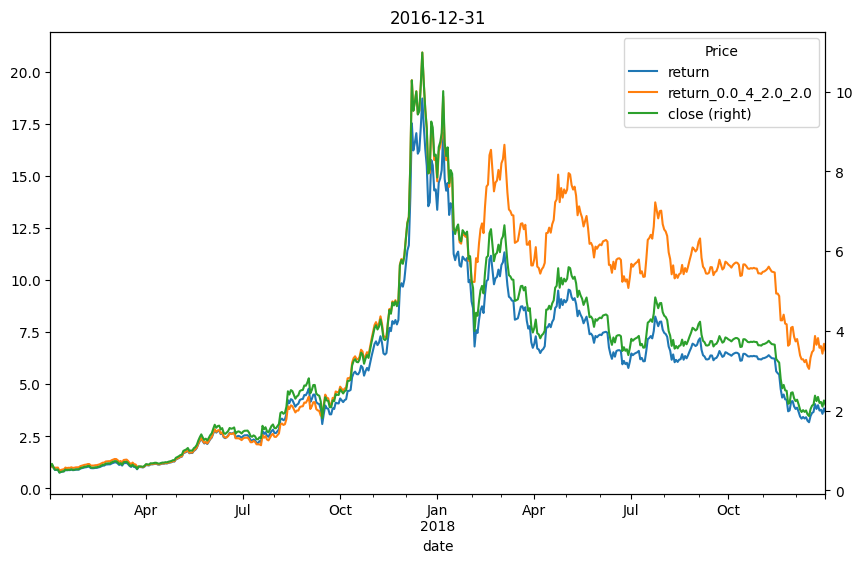

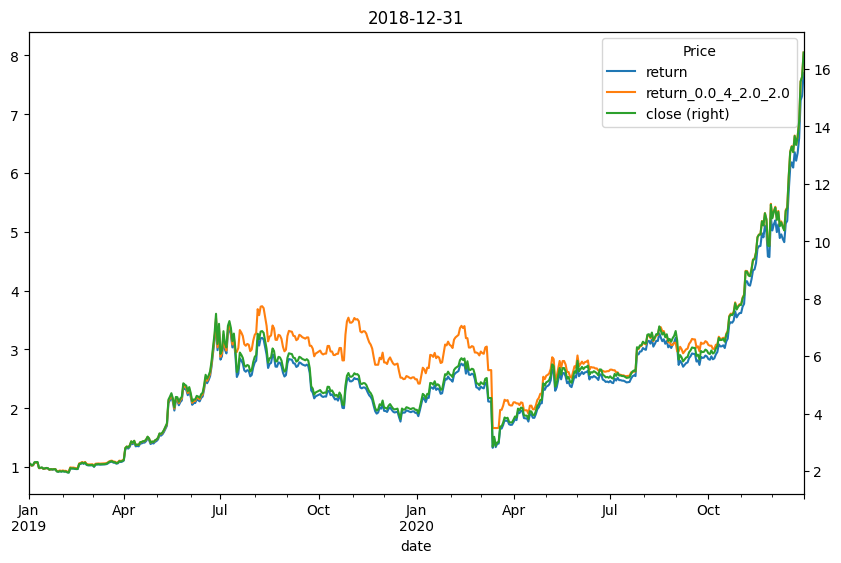

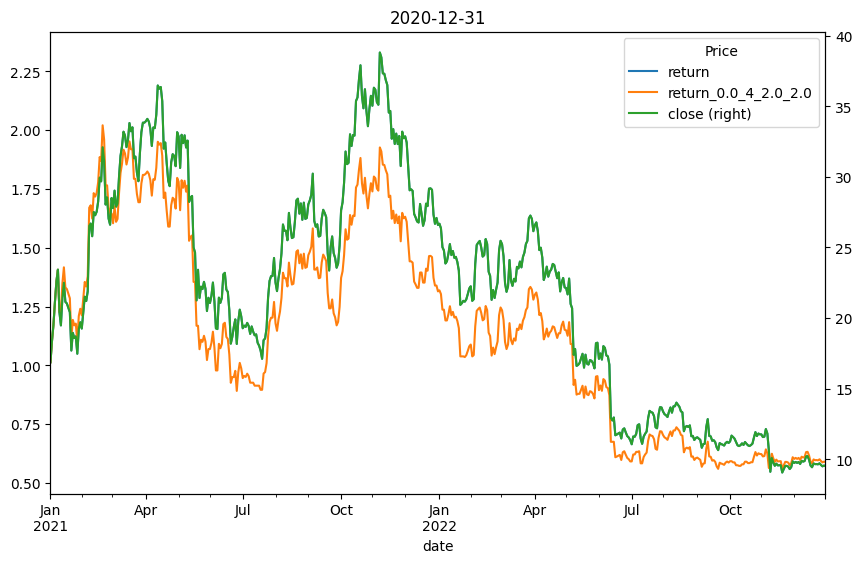

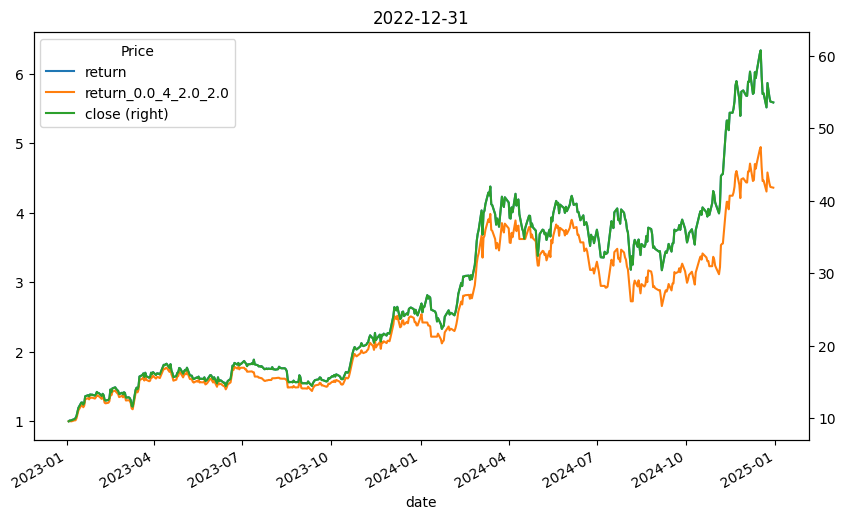

In [ ]:
num_std, window, num_dyn_stop_loss, num_static_stop_loss = 0., 4, 2.0, 2.0
for launch_point in backtest_launch_points:
    output_backtest = trend_following(num_std, window, num_dyn_stop_loss, num_static_stop_loss, data_train, launch_point, look_back_window, backtest_length, 0)
    # drop the added last row
    output_backtest = output_backtest.dropna()
    output_backtest[["return", f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]].cumsum().apply(np.exp).plot(figsize=(10, 6), title = launch_point)
    # output_backtest[["open_price"]].plot(figsize=(10, 6))
    # output_backtest[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"].plot(secondary_y = True, legend = "position")
    output_backtest["close"].plot(secondary_y = True, legend = "close")

## Forecast

In [ ]:
num_std, window, num_dyn_stop_loss, num_static_stop_loss = 0., 4, 2.0, 2.0
launch_point = input("Enter launch point in YYYY-MM-DD: ")
launch_position = int(input("Enter launch position (0 or 1): "))
print(f"launch point = {launch_point}")
print(f"launch position = {launch_position}")
output_test = trend_following(num_std, window, num_dyn_stop_loss, num_static_stop_loss, data_test, launch_point, look_back_window, backtest_length, launch_position)
new_row = {
    "num_std": num_std,
    "window": window,
    "num_dyn_stop_loss": num_dyn_stop_loss,
    "num_static_stop_loss": num_static_stop_loss,
    "launch_point": launch_point,
    "num_transaction_per_year": annual_num_transaction(output_test[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
    "annual_return": annual_return(output_test[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
    "annual_vol": annual_volatility(output_test[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
    "cum_return": cum_return(output_test[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
    "max_drawdown": max_drawdown(output_test[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]),
    "information_ratio": information_ratio(output_test[f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"], output_test["return"])
}

Enter launch point in YYYY-MM-DD: 2024-10-07
Enter launch position (0 or 1): 0
launch point = 2024-10-07
launch position = 0


In [ ]:
new_row

{'num_std': 0.0,
 'window': 4,
 'num_dyn_stop_loss': 2.0,
 'num_static_stop_loss': 2.0,
 'launch_point': '2024-10-07',
 'num_transaction_per_year': np.float64(25.099601593625497),
 'annual_return': np.float64(0.5563508591525491),
 'annual_vol': 0.43347632418257614,
 'cum_return': nan,
 'max_drawdown': 0.24560858091933738,
 'information_ratio': np.float64(-0.7485263717710873)}

<Axes: >

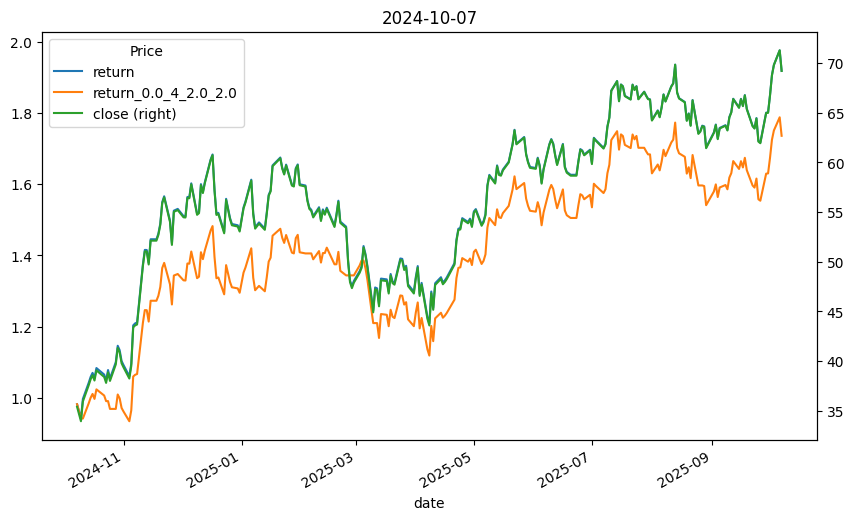

In [ ]:
output_test[["return", f"return_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"]].cumsum().apply(np.exp).plot(figsize=(10, 6), title = launch_point)
# output_test[["close", f"SMA_{short_term}", f"SMA_{long_term}"]].plot(figsize=(10, 6))
# output_test[f"position_{num_std}_{window}_{num_dyn_stop_loss}_{num_static_stop_loss}"].plot(secondary_y = True, legend = "position")
output_test["close"].plot(secondary_y = True, legend = "close")

In [ ]:
output_test.tail(10)

Price,Close,High,Low,Open,Volume,Adj Close,close,open,high,low,return,SMA_4,std_4,std_4_max,position_0.0_4_2.0_2.0,return_0.0_4_2.0_2.0
date,,,,,,,,,,,,,,,,
2025-09-25,62.099998,63.430000,61.580002,63.380001,63817400.0,62.099998,62.099998,63.380001,63.430000,61.580002,-0.036678,63.395000,0.964866,1.568641,1.0,-0.036678
2025-09-26,61.939999,62.650002,61.669998,62.009998,48826000.0,61.939999,61.939999,62.009998,62.650002,61.669998,-0.002580,62.967499,1.171022,1.568641,1.0,-0.002580
2025-09-29,64.970001,65.040001,63.650002,63.720001,51102300.0,64.970001,64.970001,63.720001,65.040001,63.650002,0.047759,63.357499,1.562016,1.562016,1.0,0.047759
2025-09-30,65.000000,65.110001,64.099998,64.400002,38099900.0,65.000000,65.000000,64.400002,65.110001,64.099998,0.000462,63.502500,1.713134,1.713134,1.0,0.000462
2025-10-01,66.739998,67.230003,66.150002,66.300003,57783300.0,66.739998,66.739998,66.300003,67.230003,66.150002,0.026417,64.662499,1.994699,1.994699,1.0,0.026417
2025-10-02,68.769997,68.839996,67.370003,67.760002,62252200.0,68.769997,68.769997,67.760002,68.839996,67.370003,0.029963,66.369999,1.801275,1.994699,1.0,0.029963
2025-10-03,69.809998,70.529999,68.220001,68.605003,83244100.0,69.809998,69.809998,68.605003,70.529999,68.220001,0.015010,67.579998,2.140949,2.140949,1.0,0.015010
2025-10-06,71.290001,71.820000,70.709999,71.010002,68503800.0,71.290001,71.290001,71.010002,71.820000,70.709999,0.020979,69.152498,1.912040,2.140949,1.0,0.020979
2025-10-07,69.214996,71.000000,68.660004,70.974998,53529721.0,69.214996,69.214996,70.974998,71.000000,68.660004,-0.029539,69.771248,1.098489,2.140949,1.0,-0.029539
